In [141]:
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [142]:
seattle_df = pd.read_csv("Datasets/Seattle_Rescue_Plan.csv")

In [143]:
seattle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 13 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Program ID                                   86 non-null     int64  
 1   Dept (Full Name)                             86 non-null     object 
 2   Dept (Acronym)                               86 non-null     object 
 3   Seattle Rescue Plan                          86 non-null     object 
 4   Category of Investment                       86 non-null     object 
 5   Item Name for the Public                     86 non-null     object 
 6   Funding Source                               86 non-null     object 
 7   Item Main Objective                          86 non-null     object 
 8   Budgeted                                     86 non-null     int64  
 9   Expenditures                                 86 non-null     int64  
 10  Encu

In [144]:
print(seattle_df.shape)

print(seattle_df.columns)

(86, 13)
Index(['Program ID', 'Dept (Full Name)', 'Dept (Acronym)',
       'Seattle Rescue Plan', 'Category of Investment',
       'Item Name for the Public', 'Funding Source', 'Item Main Objective',
       'Budgeted', 'Expenditures', 'Encumbrances',
       'Total Spent  \n(Expenditures + Encumbrances)', 'Program Status'],
      dtype='object')


In [145]:
# Rename columns for ease of use
seattle_df.rename(columns={'Program ID': 'program_id', 
                   'Dept (Full Name)': 'dept_full',
                   'Dept (Acronym)': 'dept_acr',
                   'Seattle Rescue Plan': 'seattle_rescue_plan',
                   'Category of Investment': 'category',
                   'Item Name for the Public': 'public_name',
                   'Funding Source': 'funding_source',
                   'Item Main Objective': 'main_objective',
                   'Budgeted': 'budgeted',
                   'Expenditures': 'expenditures',
                   'Encumbrances': 'encumbrances',
                   'Total Spent  \n(Expenditures + Encumbrances)': 'total_spent',
                   'Program Status': 'program_status'
                   }, 
                   inplace=True)


print(seattle_df.columns)

Index(['program_id', 'dept_full', 'dept_acr', 'seattle_rescue_plan',
       'category', 'public_name', 'funding_source', 'main_objective',
       'budgeted', 'expenditures', 'encumbrances', 'total_spent',
       'program_status'],
      dtype='object')


In [146]:
print(seattle_df.head(10))

   program_id                   dept_full dept_acr seattle_rescue_plan  \
0          17  Office of Arts and Culture     ARTS                SRP1   
1          18  Office of Arts and Culture     ARTS                SRP1   
2          19  Office of Arts and Culture     ARTS                SRP1   
3          20  Office of Arts and Culture     ARTS                SRP1   
4          21  Office of Arts and Culture     ARTS                SRP1   
5          70  Office of Arts and Culture     ARTS                SRP3   
6         101  Office of Arts and Culture     ARTS                SRP4   
7           2          City Budget Office      CBO                SRP1   
8           3          City Budget Office      CBO                SRP1   
9          56          City Budget Office      CBO                SRP3   

                                    category  \
0        Community & Small Business Recovery   
1        Community & Small Business Recovery   
2        Community & Small Business Recov

In [147]:
# df['category of investment']

# print(df['total spent'].agg))

seattle_ag_df = seattle_df.groupby('category').agg(
    budget_sum = ("budgeted", "sum"),
    budget_avg = ("budgeted", "mean"),
    spending_sum = ("total_spent", "sum"),
    spending_avg = ("total_spent", "mean"),
    program_count = ("public_name", "count")
)
seattle_ag_df["budget_percent"] = (seattle_ag_df["budget_sum"] / sum(seattle_df["budgeted"]))

# Convert sum and average to millions
seattle_ag_df['budget_sum'] = seattle_ag_df['budget_sum'] / 1000000
seattle_ag_df['budget_avg'] = seattle_ag_df['budget_avg'] / 1000000
seattle_ag_df['spending_sum'] = seattle_ag_df['spending_sum'] / 1000000
seattle_ag_df['spending_avg'] = seattle_ag_df['spending_avg'] / 1000000

print(seattle_ag_df)
print("Total spending:")
print(sum(seattle_ag_df["spending_sum"]))

                                           budget_sum  budget_avg  \
category                                                            
Community & Small Business Recovery         50.958841    1.643834   
Community Safety & Mental Health             5.346540    0.891090   
Community Well-Being & Reopening Services   64.336332    2.797232   
Housing & Homelessness                     100.581031    7.737002   
Supporting City Workers & Services          80.723106    6.209470   

                                           spending_sum  spending_avg  \
category                                                                
Community & Small Business Recovery           45.919360      1.481270   
Community Safety & Mental Health               5.346540      0.891090   
Community Well-Being & Reopening Services     55.719051      2.422567   
Housing & Homelessness                        85.314397      6.562646   
Supporting City Workers & Services            71.911908      5.531685   

    

In [148]:
print(seattle_ag_df["budget_percent"])

category
Community & Small Business Recovery          0.168768
Community Safety & Mental Health             0.017707
Community Well-Being & Reopening Services    0.213072
Housing & Homelessness                       0.333109
Supporting City Workers & Services           0.267343
Name: budget_percent, dtype: float64


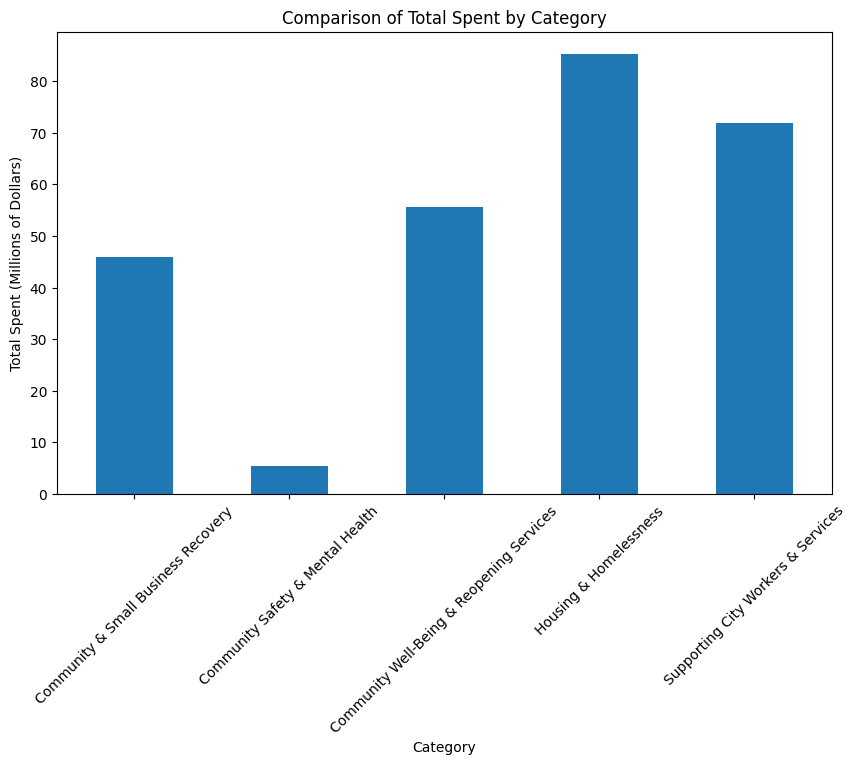

In [149]:

# Create a bar plot
seattle_ag_df['spending_sum'].plot(kind='bar', figsize=(10,6))

# Set x-tick labels as the category names
plt.xticks(ticks=range(len(seattle_ag_df)), labels=seattle_ag_df.index, rotation=45)

# Adding labels and title
plt.xlabel('Category')
plt.ylabel('Total Spent (Millions of Dollars)')
plt.title('Comparison of Total Spent by Category')

# Show the plot
plt.show()


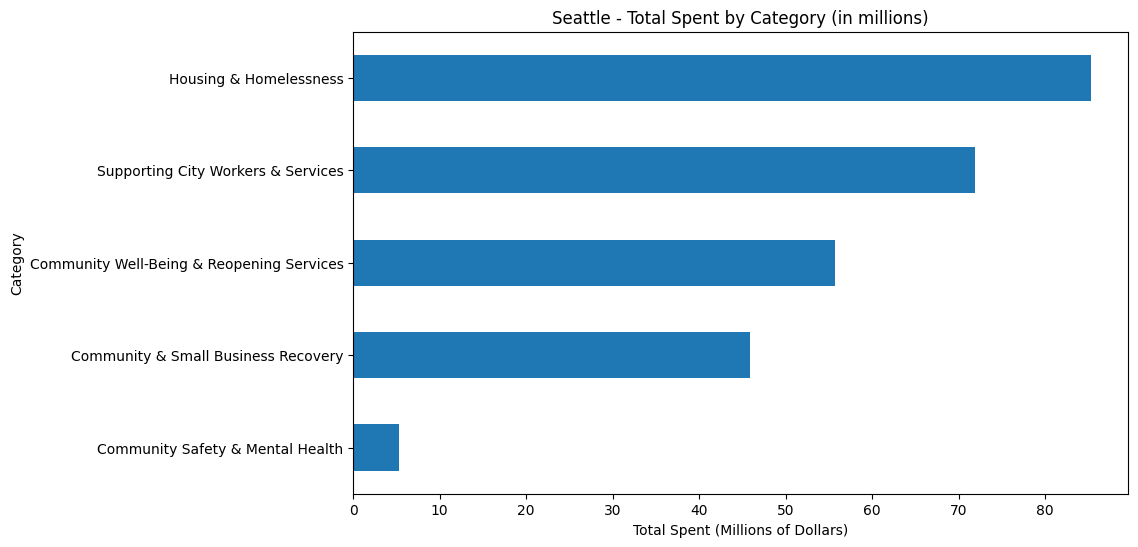

In [150]:
# Sort the DataFrame by spending_sum (ascending or descending)
sorted_df = seattle_ag_df.sort_values(by='spending_sum', ascending=True)

# Create a horizontal bar plot with the sorted data
sorted_df['spending_sum'].plot(kind='barh', figsize=(10,6))

# Set y-tick labels as the category names (handled automatically)
plt.ylabel('Category')
plt.xlabel('Total Spent (Millions of Dollars)')
plt.title('Seattle - Total Spent by Category (in millions)')

# Show the plot
plt.show()

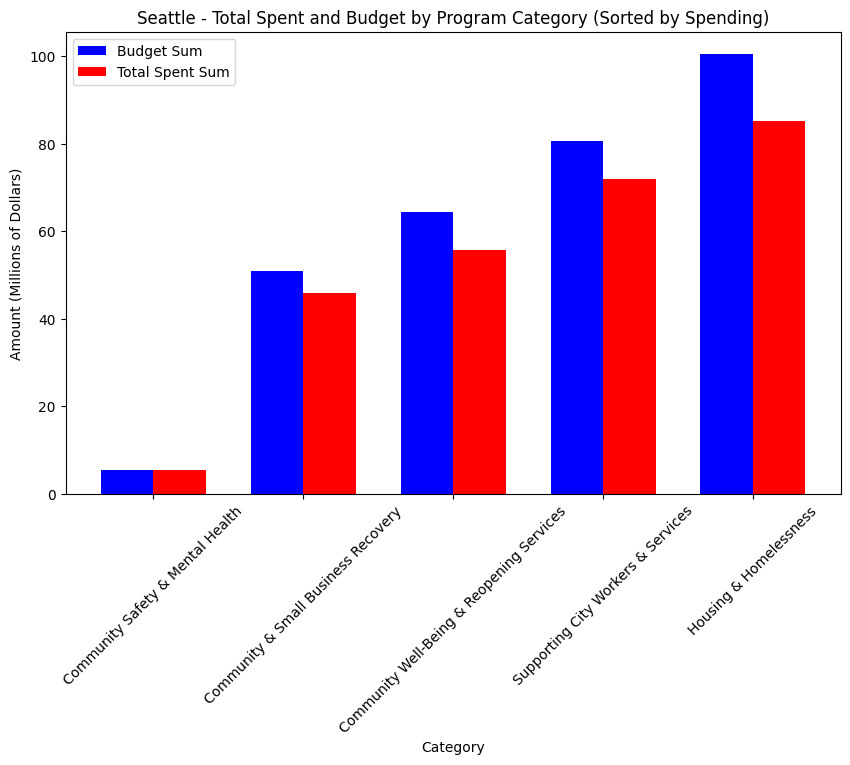

In [151]:
# Sort the DataFrame by spending_sum
sorted_df = seattle_ag_df.sort_values(by='spending_sum', ascending=True)

# Set the width of the bars
bar_width = 0.35

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create new index positions after sorting
index = np.arange(len(sorted_df))

# Plot the bars using the sorted data
ax.bar(index, sorted_df['budget_sum'], bar_width, label='Budget Sum', color='b')
ax.bar(index + bar_width, sorted_df['spending_sum'], bar_width, label='Total Spent Sum', color='r')

# Set x-tick labels using the sorted index (i.e., category names)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(sorted_df.index, rotation=45)

# Labels and title
ax.set_xlabel('Category')
ax.set_ylabel('Amount (Millions of Dollars)')
ax.set_title('Seattle - Total Spent and Budget by Program Category (Sorted by Spending)')

# Add legend
ax.legend()

# Show the plot
plt.show()


#### Seattle total_spent by category summary 

- Housing & Homelessness (85.314m)
- Supporting City Workers & Services (71.911m)
- Community Well-Being & Reopening Services (55.719m) 
- Community & Small Business Recovery (45.919m)
- Community Safety & Mental Health (5.346m)
  
Total amount spent: $264.211m

We can see the "Housing & Homelessness" was the project category that received the most funding out of Seattle's $300M budget from the ARPA with a sum total of $85.314m in spending. That was followed by "Supporting City Workers & Services" with $71.911m in spending, then "Community Well-Being & Reopening Services" with $55.719m in total spending.

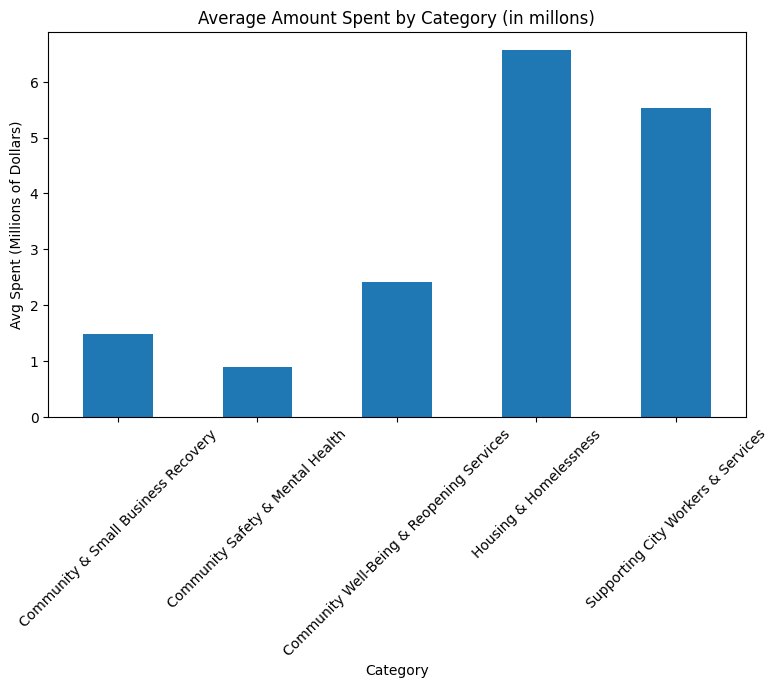

In [152]:

# Create a bar plot
seattle_ag_df['spending_avg'].plot(kind='bar', figsize=(9,5))

# Set x-tick labels as the category names
plt.xticks(ticks=range(len(seattle_ag_df)), labels=seattle_ag_df.index, rotation=45)

# Adding labels and title
plt.xlabel('Category')
plt.ylabel('Avg Spent (Millions of Dollars)')
plt.title('Average Amount Spent by Category (in millons)')

# Show the plot
plt.show()


## Now for Portland!

In [153]:
# Now for Portland data

portland_df = pd.read_csv("Datasets/Portland_Rescue_Plan_Project_Information.csv")

In [154]:
print(portland_df.shape)

print(portland_df.columns)

portland_df.info() # 6 rows where "allocation" is null

portland_df = portland_df.loc[portland_df['allocation'].notnull()]

print(portland_df.shape)

(102, 12)
Index(['OBJECTID_1', 'OBJECTID', 'project_id', 'subproject_id', 'outcome',
       'investment_area', 'selector_filter', 'name', 'allocation',
       'expenditures_to_date', 'partner_count', 'types_of_recipients'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   OBJECTID_1            102 non-null    int64  
 1   OBJECTID              102 non-null    int64  
 2   project_id            102 non-null    int64  
 3   subproject_id         102 non-null    int64  
 4   outcome               102 non-null    object 
 5   investment_area       102 non-null    object 
 6   selector_filter       102 non-null    object 
 7   name                  102 non-null    object 
 8   allocation            96 non-null     float64
 9   expenditures_to_date  102 non-null    float64
 10  partner_count         102 non-nu

In [155]:
# df['investment_area']

# print(df['expenditures_to_date'].agg))

portland_ag_df = portland_df.groupby('investment_area').agg(
    budget_sum = ("allocation", "sum"),
    budget_avg = ("allocation", "mean"),
    spending_sum = ("expenditures_to_date", "sum"),
    spending_avg = ("expenditures_to_date", "mean"),
    program_count = ("name", "count")
)

# ssum = sum(portland_ag_df["budget_sum"])
portland_ag_df["budget_percent"] = (portland_ag_df["budget_sum"] / sum(portland_df["allocation"]))
# print("HELLO:" + str(ssum))

# Convert sum and average to millions
portland_ag_df['budget_sum'] = portland_ag_df['budget_sum'] / 1000000
portland_ag_df['budget_avg'] = portland_ag_df['budget_avg'] / 1000000
portland_ag_df['spending_sum'] = portland_ag_df['spending_sum'] / 1000000
portland_ag_df['spending_avg'] = portland_ag_df['spending_avg'] / 1000000

print(portland_ag_df)
print("Total spending:")
print(sum(portland_ag_df["spending_sum"]))

                                                budget_sum  budget_avg  \
investment_area                                                          
Business and Commercial District Stabilization   60.819774    2.172135   
City of Portland Employee Resilience              3.204300    0.400537   
Community Health and Safety                      56.368508    2.168020   
Household Stabilization                         192.120420    5.650601   

                                                spending_sum  spending_avg  \
investment_area                                                              
Business and Commercial District Stabilization     48.941713      1.747918   
City of Portland Employee Resilience                1.434642      0.179330   
Community Health and Safety                        37.203577      1.430907   
Household Stabilization                           164.508587      4.838488   

                                                program_count  budget_percent  
invest

In [156]:
print(portland_ag_df["budget_percent"])

investment_area
Business and Commercial District Stabilization    0.194615
City of Portland Employee Resilience              0.010253
Community Health and Safety                       0.180372
Household Stabilization                           0.614760
Name: budget_percent, dtype: float64


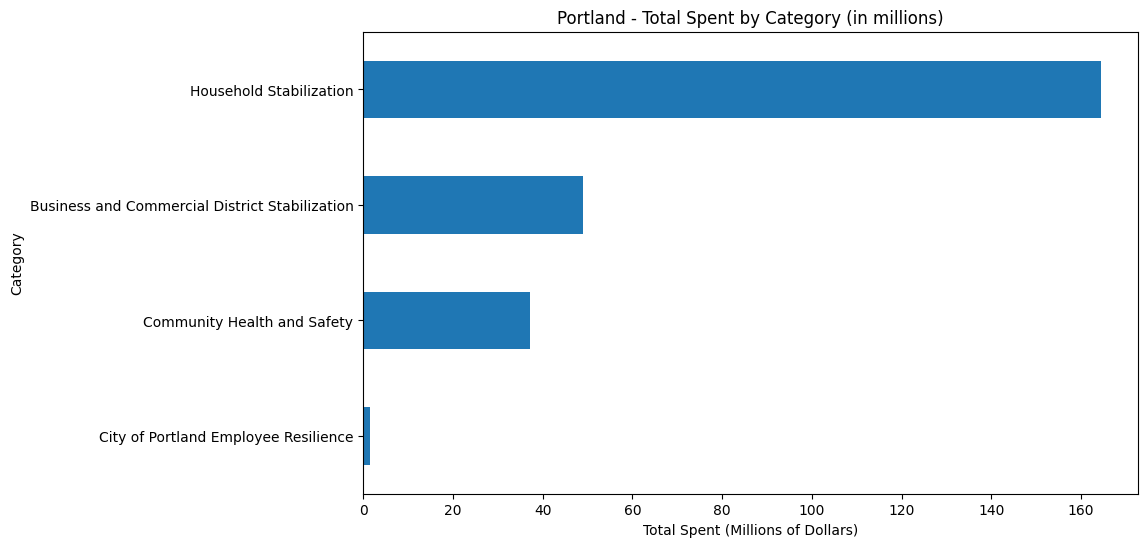

In [157]:
# Sort the DataFrame by spending_sum (ascending or descending)
sorted_df = portland_ag_df.sort_values(by='spending_sum', ascending=True)

# Create a horizontal bar plot with the sorted data
sorted_df['spending_sum'].plot(kind='barh', figsize=(10,6))

# Set y-tick labels as the category names (handled automatically)
plt.ylabel('Category')
plt.xlabel('Total Spent (Millions of Dollars)')
plt.title('Portland - Total Spent by Category (in millions)')

# Show the plot
plt.show()


#### Portland expenditures_to_date by category summary 

- Household Stabilization (164.508m)
- Business and Commercial District Stabilization (48.941m)   
- Community Health and Safety (37.203m)         
- City of Portland Employee Resilience (1.434m)   

Total spending: $252.088m

Note: Portland received  $208 million from the ARPA, but also received the following through the CARES act: 
- $114,247,256 of Coronavirus Relief Funds
- $9,640,943 of Community Development Block Grant
- $16,979,685 of Emergency Solutions Grant
- $249,909 of Housing Opportunities for People with AIDS

Like Seattle, we can see Portland's top spending category was "Household Stabilization" with $164.508m in spending, then "Business and Commercial District Stabilization with $48.941m in spending, and then "Community Health and Safety" with $37.203m in spending.

   

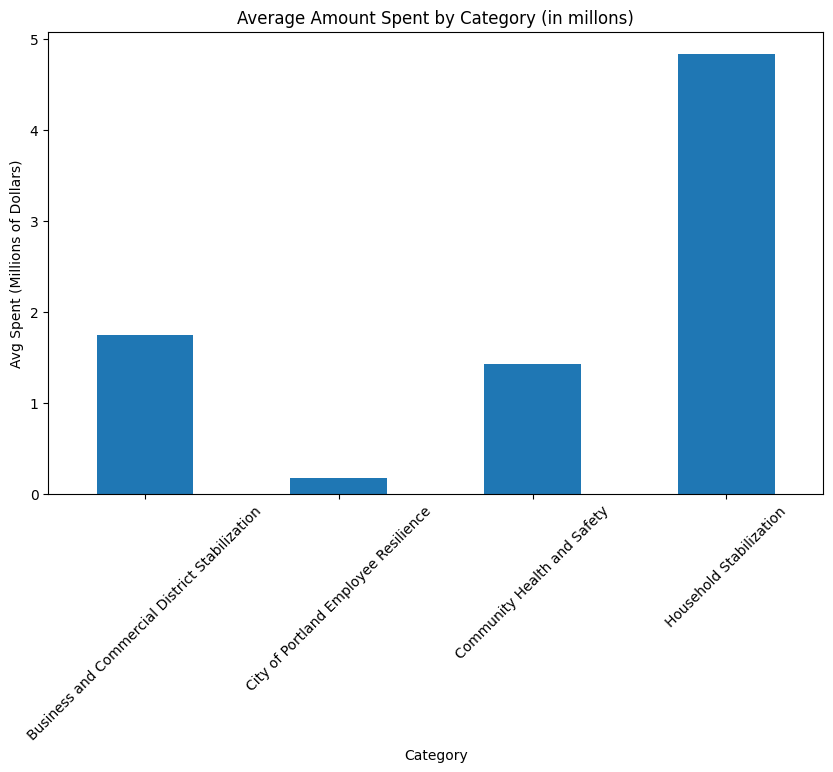

In [158]:

# Create a bar plot
portland_ag_df['spending_avg'].plot(kind='bar', figsize=(10,6))

# Set x-tick labels as the category names
plt.xticks(ticks=range(len(portland_ag_df)), labels=portland_ag_df.index, rotation=45)

# Adding labels and title
plt.xlabel('Category')
plt.ylabel('Avg Spent (Millions of Dollars)')
plt.title('Average Amount Spent by Category (in millons)')

# Show the plot
plt.show()


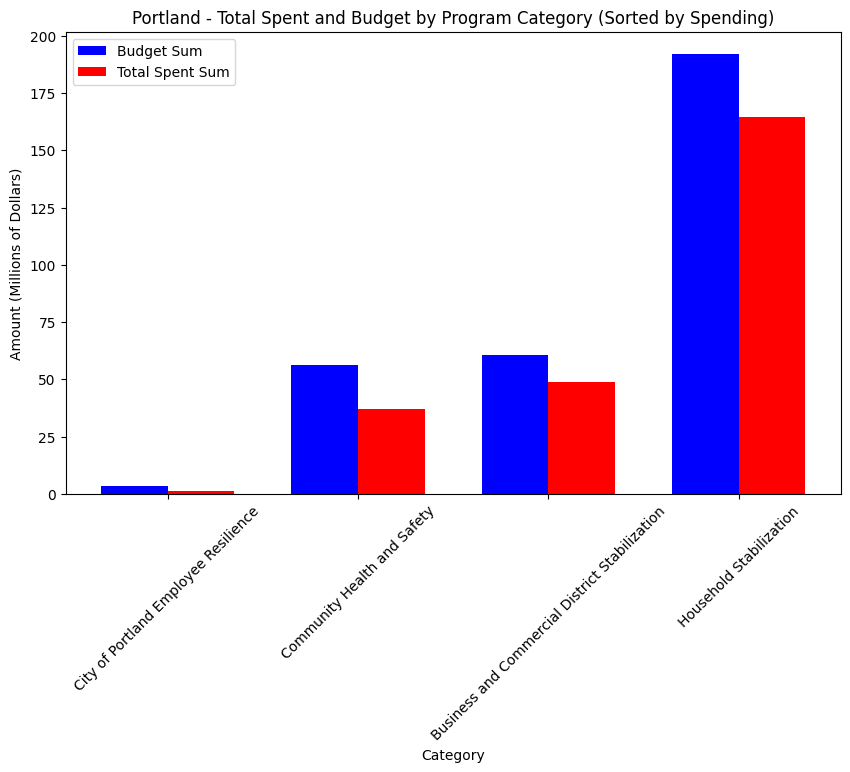

In [159]:
# Sort the DataFrame by spending_sum
sorted_df = portland_ag_df.sort_values(by='spending_sum', ascending=True)

# Set the width of the bars
bar_width = 0.35

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create new index positions after sorting
index = np.arange(len(sorted_df))

# Plot the bars using the sorted data
ax.bar(index, sorted_df['budget_sum'], bar_width, label='Budget Sum', color='b')
ax.bar(index + bar_width, sorted_df['spending_sum'], bar_width, label='Total Spent Sum', color='r')

# Set x-tick labels using the sorted index (i.e., category names)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(sorted_df.index, rotation=45)

# Labels and title
ax.set_xlabel('Category')
ax.set_ylabel('Amount (Millions of Dollars)')
ax.set_title('Portland - Total Spent and Budget by Program Category (Sorted by Spending)')

# Add legend
ax.legend()

# Show the plot
plt.show()


#### Categories 

#### Seattle
- Community & Small Business Recovery                     
- Community Safety & Mental Health                       
- Community Well-Being & Reopening Services               
- Housing & Homelessness                                
- Supporting City Workers & Services        

#### Portland
- Business and Commercial District Stabilization               
- City of Portland Employee Resilience                          
- Community Health and Safety                                  
- Household Stabilization             


#### Alignment Between Cities
- Community & small business recovery = Business and Commercial District Stabilization ?
- Community safety & mental health = community health and safety
- Community well-being & reopening services = ????
- Housing and homelessness = household stabilization
- Supporting city workers & services =  City of Portland Employee Resilience